# 📊 Huấn luyện Hai Model Transformer Riêng biệt cho Apartment & Landed House (Có Đặc trưng Tỉnh/Thành)

Notebook này hướng dẫn chi tiết cách xây dựng và huấn luyện độc lập hai mạng nơ-ron Transformer để dự đoán giá bất động sản:
- **Model Apartment:** Huấn luyện trên dữ liệu chung cư, loại bỏ các đặc trưng không liên quan như số tầng (`floors_num`), mặt tiền (`frontage_m`), đường rộng (`road_width_m`).
- **Model Landed House:** Huấn luyện trên dữ liệu nhà đất, giữ nguyên tất cả đặc trưng.

Cả hai mô hình đều được huấn luyện trên quy mô toàn quốc, sử dụng cột địa lý vĩ mô cấp tỉnh (`city`). Kết quả sau huấn luyện sẽ được xuất thành hai file model độc lập để phục vụ dự đoán chính xác nhất.

## 1. Thiết lập Môi trường & Thiết bị Huấn luyện
Chúng ta sẽ import các thư viện khoa học dữ liệu cơ bản, thiết lập cơ chế đồng nhất kết quả (random seed = 42) và tự động nhận diện phần cứng tăng tốc như Apple Metal Performance Shaders (MPS) hoặc CUDA.

In [1]:
import os
import sys
import json
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBRegressor

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 240)

warnings.filterwarnings('ignore')

def print_section(title: str) -> None:
    print('\n' + '=' * 90)
    print(title)
    print('=' * 90)

# Thiết lập seed
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(42)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Định nghĩa đường dẫn thư mục
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name in ['transformer', 'notebooks']:
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

sys.path.append(str(PROJECT_ROOT))
from transformer_model import HousePriceTransformer

OUTPUT_DIR = PROJECT_ROOT / 'models' / 'transformer' / 'national'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print_section('0. THIẾT LẬP MÔI TRƯỜNG THÀNH CÔNG')
print(f'Thiết bị sử dụng: {device}')
print(f'Thư mục lưu mô hình: {OUTPUT_DIR}')


0. THIẾT LẬP MÔI TRƯỜNG THÀNH CÔNG
Thiết bị sử dụng: mps
Thư mục lưu mô hình: /Users/tangoctai/Downloads/House-Price-Prediction-main 2/models/transformer/national


## 2. Đọc và Tiền xử lý dữ liệu độc lập cho 2 nhóm BĐS
Ở bước này, chúng ta tiến hành tải dữ liệu độc lập cho **Apartment** và **Landed House**. Sau đó thực hiện lọc outliers để loại bỏ các điểm dữ liệu dị thường (ví dụ: giá quá cao/thấp hoặc diện tích không hợp lý).

In [2]:
cc_path = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_chung_cu.csv'
nd_path = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_nha_dat.csv'
df_cc = pd.read_csv(cc_path)
df_nd = pd.read_csv(nd_path)

print_section('1. ĐỌC DỮ LIỆU ĐẦU VÀO')
print(f'Số dòng chung cư ban đầu : {len(df_cc):,}')
print(f'Số dòng nhà đất ban đầu  : {len(df_nd):,}')

# Lọc outliers Apartment
df_cc_clean = df_cc.copy()
if 'balcony_direction' in df_cc_clean.columns:
    df_cc_clean = df_cc_clean.drop(columns=['balcony_direction'])
df_cc_clean = df_cc_clean.dropna(subset=['price_billion', 'area_m2'])
df_cc_clean = df_cc_clean[(df_cc_clean['price_billion'] >= 1) & (df_cc_clean['price_billion'] <= 200)]
df_cc_clean = df_cc_clean[(df_cc_clean['area_m2'] >= 10) & (df_cc_clean['area_m2'] <= 1000)]

# Lọc outliers Landed House
df_nd_clean = df_nd.copy()
df_nd_clean = df_nd_clean.dropna(subset=['price_billion', 'area_m2'])
df_nd_clean = df_nd_clean[(df_nd_clean['price_billion'] >= 1) & (df_nd_clean['price_billion'] <= 200)]
df_nd_clean = df_nd_clean[(df_nd_clean['area_m2'] >= 10) & (df_nd_clean['area_m2'] <= 1000)]

# Đồng nhất kiểu dữ liệu phân loại
for col in ['city', 'district', 'direction', 'furniture_std', 'legal_std']:
    if col in df_cc_clean.columns: df_cc_clean[col] = df_cc_clean[col].astype(str).str.strip()
    if col in df_nd_clean.columns: df_nd_clean[col] = df_nd_clean[col].astype(str).str.strip()

print_section('2. KẾT QUẢ SAU LỌC OUTLIERS')
print(f'Apartment dùng huấn luyện: {len(df_cc_clean):,} dòng')
print(f'Landed House dùng huấn luyện : {len(df_nd_clean):,} dòng')


1. ĐỌC DỮ LIỆU ĐẦU VÀO
Số dòng chung cư ban đầu : 5,452
Số dòng nhà đất ban đầu  : 6,379

2. KẾT QUẢ SAU LỌC OUTLIERS
Apartment dùng huấn luyện: 5,446 dòng
Landed House dùng huấn luyện : 6,340 dòng


## 3. Các hàm hỗ trợ chuyển đổi Đặc trưng & Tạo Dataloader
Để nạp dữ liệu bảng vào PyTorch Transformer, ta cần:
1. **Mã hóa nhãn phân loại (Label Encoding)**: Đổi các cột chữ như `district`, `direction` thành mã số (1, 2, ..., K) để đưa vào tầng Embedding.
2. **Chuẩn hóa biến số (Standardization)**: Đổi các cột số thành phân phối chuẩn có $\mu=0$ và $\sigma=1$ bằng `StandardScaler`.
3. **Tạo DataLoader**: Đóng gói các tensor số, phân loại và giá nhà thành các batch dữ liệu để tối ưu hóa bộ nhớ GPU/CPU khi huấn luyện.

In [3]:
def make_category_mappings(train_df, cat_features):
    """Tạo bảng mã hóa (mapping) cho các cột phân loại dựa trên tập train."""
    mappings = {}
    for col in cat_features:
        values = sorted(train_df[col].astype(str).unique())
        mappings[col] = {value: idx + 1 for idx, value in enumerate(values)}
    return mappings

def encode_categories(df, cat_features, mappings):
    """Áp dụng bảng mã hóa vào dataframe."""
    encoded = []
    for col in cat_features:
        mapping = mappings[col]
        encoded.append(df[col].astype(str).map(mapping).fillna(0).astype('int64').to_numpy())
    return np.stack(encoded, axis=1)

def make_loader(numeric_array, categorical_array, target_array, batch_size, shuffle):
    """Đóng gói dữ liệu thành PyTorch DataLoader."""
    dataset = TensorDataset(
        torch.tensor(numeric_array, dtype=torch.float32),
        torch.tensor(categorical_array, dtype=torch.long),
        torch.tensor(target_array, dtype=torch.float32)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

def evaluate(model, loader, device, criterion):
    """Đánh giá mô hình trên DataLoader bất kỳ và tính toán lỗi MSE."""
    model.eval()
    losses = []
    preds = []
    actuals = []
    with torch.no_grad():
        for num_vals, cat_ids, y in loader:
            num_vals = num_vals.to(device)
            cat_ids = cat_ids.to(device)
            y = y.to(device)
            output = model(num_vals, cat_ids)
            loss = criterion(output, y)
            losses.append(float(loss.item()) * len(y))
            preds.append(output.cpu().numpy())
            actuals.append(y.cpu().numpy())

    y_pred = np.concatenate(preds)
    y_true = np.concatenate(actuals)
    return sum(losses) / len(y_true), y_pred, y_true

def regression_metrics(y_true, y_pred):
    """Tính toán các chỉ số lỗi đo lường hồi quy."""
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        'MSE': float(mean_squared_error(y_true, y_pred)),
        'RMSE': rmse,
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred)),
        'MAPE': float(mean_absolute_percentage_error(y_true, y_pred))
    }

## 4. Xây dựng Hàm Huấn luyện tuần tự với Early Stopping
Hàm `train_and_save_model` thực thi việc huấn luyện và so sánh mô hình mạng nơ-ron Transformer PyTorch với baseline XGBoost trên **cùng tập Test 15%** để đảm bảo tính khách quan tối đa.

In [4]:
def train_and_save_model(df_clean, label, num_features, cat_features, target_col, device, epochs=80, batch_size=64, patience=10):
    print_section(f'BẮT ĐẦU HUẤN LUYỆN MODEL CHO: {label.upper()}')
    
    # 1. Chia Train/Val/Test
    train_val_df, test_df = train_test_split(df_clean, test_size=0.15, random_state=42)
    train_df, val_df = train_test_split(train_val_df, test_size=0.1765, random_state=42)
    print(f'Số mẫu phân chia: Train = {len(train_df):,} | Val = {len(val_df):,} | Test = {len(test_df):,}')

    # 2. StandardScaler các biến số
    scaler = StandardScaler()
    train_num = scaler.fit_transform(train_df[num_features])
    val_num = scaler.transform(val_df[num_features])
    test_num = scaler.transform(test_df[num_features])

    # 3. Label encoding
    mappings = make_category_mappings(train_df, cat_features)
    train_cat = encode_categories(train_df, cat_features, mappings)
    val_cat = encode_categories(val_df, cat_features, mappings)
    test_cat = encode_categories(test_df, cat_features, mappings)

    y_train = train_df[target_col].to_numpy(dtype=np.float32)
    y_val = val_df[target_col].to_numpy(dtype=np.float32)
    y_test = test_df[target_col].to_numpy(dtype=np.float32)

    train_loader = make_loader(train_num, train_cat, y_train, batch_size, shuffle=True)
    val_loader = make_loader(val_num, val_cat, y_val, batch_size, shuffle=False)
    test_loader = make_loader(test_num, test_cat, y_test, batch_size, shuffle=False)

    # 4. Khởi tạo mạng Transformer
    categorical_cardinalities = [len(mappings[col]) + 1 for col in cat_features]
    model = HousePriceTransformer(
        num_numeric=len(num_features),
        categorical_cardinalities=categorical_cardinalities,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.2
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    best_val_loss = float('inf')
    best_epoch = 0
    wait = 0
    history = []
    suffix = 'cc' if label == 'Apartment' else 'nd'
    best_state_path = OUTPUT_DIR / f'transformer_model_{suffix}.pt'

    # Vòng lặp huấn luyện mạng nơ-ron
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        seen = 0
        for num_vals, cat_ids, y in train_loader:
            num_vals = num_vals.to(device)
            cat_ids = cat_ids.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            output = model(num_vals, cat_ids)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item()) * len(y)
            seen += len(y)

        train_mse = total_loss / seen
        val_mse, _, _ = evaluate(model, val_loader, device, criterion)
        history.append({'epoch': epoch, 'train_mse': train_mse, 'val_mse': val_mse})

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:03d} | Train MSE = {train_mse:.4f} | Validation MSE = {val_mse:.4f}')

        # Dừng sớm nếu validation loss không cải thiện
        if val_mse < best_val_loss:
            best_val_loss = val_mse
            best_epoch = epoch
            wait = 0
            torch.save({
                'state_dict': model.state_dict(),
                'model_params': {
                    'num_numeric': len(num_features),
                    'categorical_cardinalities': categorical_cardinalities,
                    'd_model': 64,
                    'nhead': 4,
                    'num_layers': 2,
                    'dim_feedforward': 128,
                    'dropout': 0.2
                },
                'features': num_features + cat_features,
                'numeric_features': num_features,
                'categorical_features': cat_features,
                'target': target_col
            }, best_state_path)
        else:
            wait += 1
            if wait >= patience:
                print(f'>> Early Stopping kích hoạt ở epoch {epoch}. Epoch tốt nhất chọn: {best_epoch}')
                break

    # Đọc lại trọng số tối ưu nhất
    checkpoint = torch.load(best_state_path, map_location=device)
    model.load_state_dict(checkpoint['state_dict'])

    # Tính toán chỉ số test
    test_mse, test_pred, test_true = evaluate(model, test_loader, device, criterion)
    test_metrics = regression_metrics(test_true, test_pred)

    # Lưu bộ preprocessing
    preprocessing = {
        'scaler': scaler,
        'category_mappings': mappings,
        'numeric_features': num_features,
        'categorical_features': cat_features,
        'features': num_features + cat_features,
        'target': target_col
    }
    with open(OUTPUT_DIR / f'preprocessing_{suffix}.pkl', 'wb') as f:
        pickle.dump(preprocessing, f)

    # Vẽ biểu đồ Loss Curve
    epochs_list = [item['epoch'] for item in history]
    plt.figure(figsize=(7, 4.5))
    plt.plot(epochs_list, [item['train_mse'] for item in history], label='Train MSE')
    plt.plot(epochs_list, [item['val_mse'] for item in history], label='Validation MSE')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.title(f'Loss Curve - Transformer ({label})')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'training_loss_{suffix}.png', dpi=150)
    plt.close()

    # Baseline XGBoost (Được huấn luyện và kiểm thử trên CÙNG TẬP dữ liệu và tỷ lệ split 15% test như Transformer)
    xgb = XGBRegressor(n_estimators=100, random_state=42)
    X_train_xgb = np.hstack([train_num, train_cat])
    X_test_xgb = np.hstack([test_num, test_cat])
    xgb.fit(X_train_xgb, y_train)
    xgb_pred = xgb.predict(X_test_xgb)
    xgb_metrics = regression_metrics(y_test, xgb_pred)

    return test_metrics, xgb_metrics

## 5. Thực thi Huấn luyện mô hình Apartment & Landed House
Chúng ta huấn luyện mô hình cho cả Apartment và Landed House một cách tuần tự.

In [5]:
num_cc = ['area_m2', 'bedrooms_num']
cat_cc = ['city', 'district', 'direction', 'furniture_std', 'legal_std']

num_nd = ['area_m2', 'bedrooms_num', 'floors_num', 'frontage_m', 'road_width_m']
cat_nd = ['city', 'district', 'direction', 'furniture_std', 'legal_std']

# Chạy Apartment
metrics_cc, xgb_cc = train_and_save_model(
    df_cc_clean, 'Apartment', num_cc, cat_cc, 'price_billion', device, epochs=80
)

# Chạy Landed House
metrics_nd, xgb_nd = train_and_save_model(
    df_nd_clean, 'Landed House', num_nd, cat_nd, 'price_billion', device, epochs=80
)


BẮT ĐẦU HUẤN LUYỆN MODEL CHO: APARTMENT
Số mẫu phân chia: Train = 3,811 | Val = 818 | Test = 817


Epoch 001 | Train MSE = 47.3606 | Validation MSE = 33.1606


Epoch 010 | Train MSE = 12.9568 | Validation MSE = 12.9539


Epoch 020 | Train MSE = 12.1703 | Validation MSE = 14.6200


>> Early Stopping kích hoạt ở epoch 25. Epoch tốt nhất chọn: 15



BẮT ĐẦU HUẤN LUYỆN MODEL CHO: LANDED HOUSE
Số mẫu phân chia: Train = 4,437 | Val = 952 | Test = 951


Epoch 001 | Train MSE = 186.8705 | Validation MSE = 128.8891


Epoch 010 | Train MSE = 40.2748 | Validation MSE = 42.5072


Epoch 020 | Train MSE = 31.9149 | Validation MSE = 43.4395


>> Early Stopping kích hoạt ở epoch 26. Epoch tốt nhất chọn: 16


## 6. Trình bày & Đối chiếu kết quả dự đoán (R², MAE, RMSE, MAPE, MSE)
Chúng ta biểu diễn kết quả dự đoán của mô hình mạng nơ-ron Transformer và mô hình XGBoost Baseline dạng bảng Pandas để đánh giá trực quan và lưu trữ kết quả này vào file CSV.


BẢNG ĐỐI CHIẾU HIỆU NĂNG TRÊN TẬP KIỂM THỬ (TEST SET)


,Property Type,Model,R2,MAE,RMSE,MAPE,MSE
0,Apartment,Transformer,0.6451,1.7821,3.1608,26.4%,9.9908
1,Apartment,XGBoost,0.6541,1.7650,3.1203,27.0%,9.7364
2,Landed House,Transformer,0.7285,3.2918,6.1576,30.1%,37.9166
3,Landed House,XGBoost,0.6717,3.3539,6.7706,28.5%,45.8406



✅ Đã xuất toàn bộ các chỉ số so sánh vào file CSV: /Users/tangoctai/Downloads/House-Price-Prediction-main 2/models/transformer/national/comparison_with_xgboost.csv


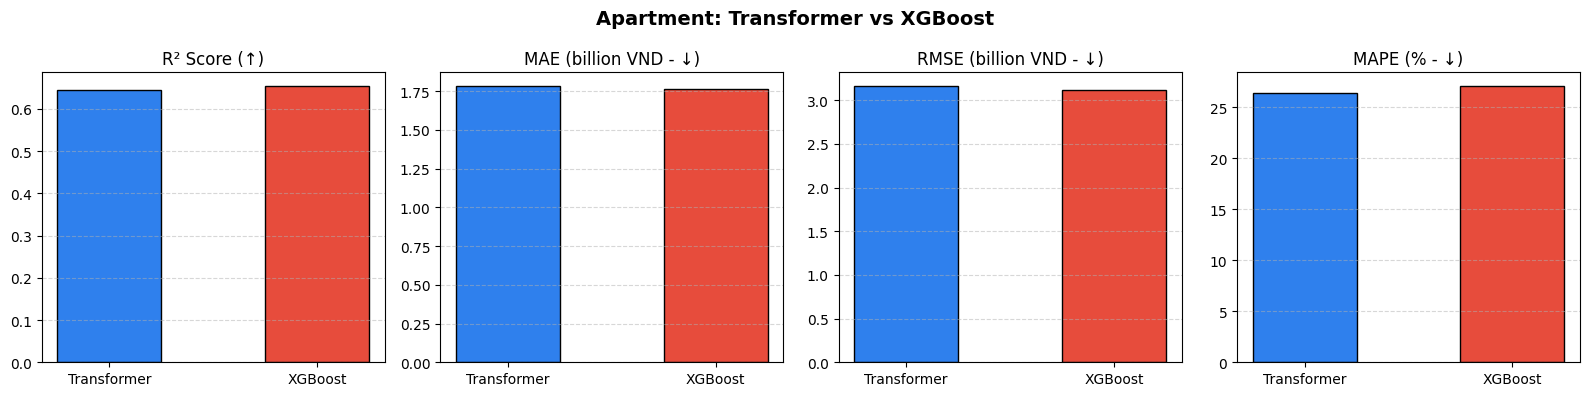

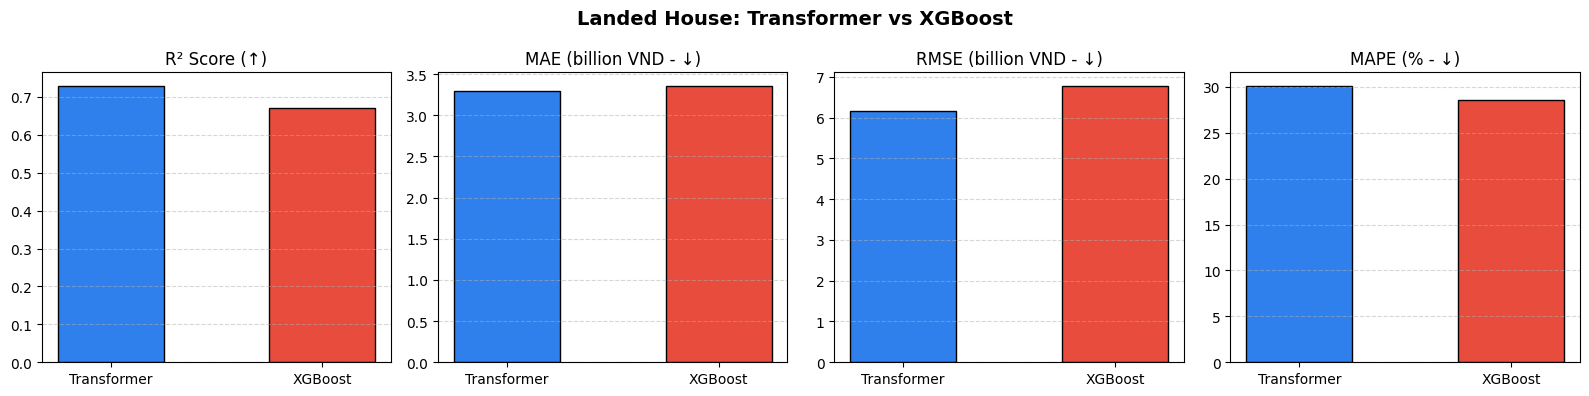


✅ Đã lưu các biểu đồ so sánh đầy đủ 4 chỉ số vào outputs!


In [6]:
print_section('BẢNG ĐỐI CHIẾU HIỆU NĂNG TRÊN TẬP KIỂM THỬ (TEST SET)')

comparison_df = pd.DataFrame([
    {'Property Type': 'Apartment', 'Model': 'Transformer', 'R2': metrics_cc['R2'], 'MAE': metrics_cc['MAE'], 'RMSE': metrics_cc['RMSE'], 'MAPE': metrics_cc['MAPE'], 'MSE': metrics_cc['MSE']},
    {'Property Type': 'Apartment', 'Model': 'XGBoost', 'R2': xgb_cc['R2'], 'MAE': xgb_cc['MAE'], 'RMSE': xgb_cc['RMSE'], 'MAPE': xgb_cc['MAPE'], 'MSE': xgb_cc['MSE']},
    {'Property Type': 'Landed House', 'Model': 'Transformer', 'R2': metrics_nd['R2'], 'MAE': metrics_nd['MAE'], 'RMSE': metrics_nd['RMSE'], 'MAPE': metrics_nd['MAPE'], 'MSE': metrics_nd['MSE']},
    {'Property Type': 'Landed House', 'Model': 'XGBoost', 'R2': xgb_nd['R2'], 'MAE': xgb_nd['MAE'], 'RMSE': xgb_nd['RMSE'], 'MAPE': xgb_nd['MAPE'], 'MSE': xgb_nd['MSE']}
])

display(comparison_df.style.format({
    'R2': '{:.4f}', 'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'MAPE': '{:.1%}', 'MSE': '{:.4f}'
}).set_properties(**{
    'text-align': 'left', 'vertical-align': 'middle'
}))

# Xuất toàn bộ các giá trị so sánh sang file CSV
comparison_df.to_csv(OUTPUT_DIR / 'comparison_with_xgboost.csv', index=False)
print(f'\n✅ Đã xuất toàn bộ các chỉ số so sánh vào file CSV: {OUTPUT_DIR / "comparison_with_xgboost.csv"}')

# Hàm vẽ biểu đồ so sánh đầy đủ 4 chỉ số
def draw_metrics_chart(trans_m, xgb_m, title, filename):
    labels = ['Transformer', 'XGBoost']
    colors = ['#2f80ed', '#e74c3c']
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(title, fontweight='bold', fontsize=14)
    
    # R2
    axes[0].bar(labels, [trans_m['R2'], xgb_m['R2']], color=colors, edgecolor='black', width=0.5)
    axes[0].set_title('R² Score (↑)')
    axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # MAE
    axes[1].bar(labels, [trans_m['MAE'], xgb_m['MAE']], color=colors, edgecolor='black', width=0.5)
    axes[1].set_title('MAE (billion VND - ↓)')
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # RMSE
    axes[2].bar(labels, [trans_m['RMSE'], xgb_m['RMSE']], color=colors, edgecolor='black', width=0.5)
    axes[2].set_title('RMSE (billion VND - ↓)')
    axes[2].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # MAPE
    axes[3].bar(labels, [trans_m['MAPE'] * 100, xgb_m['MAPE'] * 100], color=colors, edgecolor='black', width=0.5)
    axes[3].set_title('MAPE (% - ↓)')
    axes[3].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()

draw_metrics_chart(metrics_cc, xgb_cc, 'Apartment: Transformer vs XGBoost', 'transformer_vs_xgboost_cc.png')
draw_metrics_chart(metrics_nd, xgb_nd, 'Landed House: Transformer vs XGBoost', 'transformer_vs_xgboost_nd.png')
print(f'\n✅ Đã lưu các biểu đồ so sánh đầy đủ 4 chỉ số vào outputs!')